In [50]:
import pandas as pd
import numpy as np

import seaborn as sns
import sklearn

data_book = pd.read_csv("Challenge 1 - data_ml_books_openlibrary.csv")

data_book.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               500 non-null    object 
 1   authors             495 non-null    object 
 2   first_publish_year  498 non-null    float64
 3   edition_count       500 non-null    int64  
 4   publishers          0 non-null      float64
 5   isbn                0 non-null      float64
 6   subjects            198 non-null    object 
 7   description         34 non-null     object 
dtypes: float64(3), int64(1), object(4)
memory usage: 31.4+ KB


# Title: Challenge 1 - A recommender system for online shops

### Description:

You are a data scientist working for an online retail company. Your task is to build a recommender system for an online marketplace. The recommender system is basically a python code that suggests a list of five top books on “machine learning”. The criteria used by this recommender system includes year of publication (the more recent, the better), number of editions (the higher the better), and useful for “python”.
In reality, you, as a data scientist, should opt for retrieving real data from online platforms/shops. Since this is the first challenge, it is decided to start from a simple task. Thus, a real dataset from https://openlibrary.org was obtained and passed to you as the main dataset required in this challenge for developing the recommender system.
The dataset is in CSV format. It includes a list of 500 books. Since the data is real, it may include books not correctly related to the machine learning topic even though the keyword “machine learning” was used for collecting this dataset. In addition, the dataset may have missing information, duplicated entries, book names in other languages than English that should be removed. Thus, before developing the recommender system, it is advised to clean the data.
The important factors for recommending a book is to emphasize on when the book has been published. As the domain of machine learning is evolving fast, therefore the books published in recent years can be assigned higher scores. The second important factor is the number of editions, which can be a good indicator of usefulness. Furthermore, the user would like to read about the machine learning techniques and employ such models in “python”. Therefore, including “python” in the book “title” or “subjects” or “description” can be a better option. Considering these factors, each student can develop a self-defined but justified ranking system to develop a function for recommending which book to buy. The recommender system should be tested for 3, 5, and 10 top books, while the recommended results should be in line with the requirements.
For improving the recommender system, students may enhance the main dataset by adding further information or books to the dataset. The new information can be gathered from online platforms. This is totally optional but has further points in the evaluation.
The students need to write a short report (maximum two pages) describing their solution and provide a working Python notebook.


In [51]:


authors_data= data_book["authors"].value_counts()
authors_data

authors
Machine Learning                                                             6
Ethem Alpaydin                                                               3
Oliver Theobald                                                              3
Hein Smith                                                                   3
Sebastian Raschka, Vahid Mirjalili                                           3
                                                                            ..
Dav Pilkey                                                                   1
Mohssen Mohammed, Muhammad Badruddin Khan, Ejhab Bashier Mohammed Bashier    1
Sebastian Raschka, Yuxi (Hayden) Liu, Vahid Mirjalili, Dmytro Dzhulgakov     1
Mehryar Mohri                                                                1
Kevin P. Murphy, Kevin P. Murphy                                             1
Name: count, Length: 461, dtype: int64

In [52]:


book_series_title = data_book["title"].value_counts()

book_series_title

data_book.head()

data_book.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               500 non-null    object 
 1   authors             495 non-null    object 
 2   first_publish_year  498 non-null    float64
 3   edition_count       500 non-null    int64  
 4   publishers          0 non-null      float64
 5   isbn                0 non-null      float64
 6   subjects            198 non-null    object 
 7   description         34 non-null     object 
dtypes: float64(3), int64(1), object(4)
memory usage: 31.4+ KB


In [53]:
data_book["authors"] = data_book["authors"].fillna("not specified")


data_book["description"] = data_book["description"].fillna("not specified")

data_book["subjects"] = data_book["subjects"].fillna("not specified")
data_book["first_publish_year"] = data_book["first_publish_year"].fillna(2000.0)
data_book.info()

data_book.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               500 non-null    object 
 1   authors             500 non-null    object 
 2   first_publish_year  500 non-null    float64
 3   edition_count       500 non-null    int64  
 4   publishers          0 non-null      float64
 5   isbn                0 non-null      float64
 6   subjects            500 non-null    object 
 7   description         500 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 31.4+ KB


,title,authors,first_publish_year,edition_count,publishers,isbn,subjects,description
0,Why Machines Learn,Anil Ananthaswamy,2024.0,4,NaN,NaN,Science,not specified
1,The Time Machine,H. G. Wells,1895.0,1146,NaN,NaN,"Self-experimentation in medicine in fiction, F...","The Time Traveller, a dreamer obsessed with tr..."
2,Machine learning,"Kevin P. Murphy, Kevin P. Murphy",2012.0,4,NaN,NaN,"Probabilities, Machine learning, Probability, ...","""This textbook offers a comprehensive and self..."
3,Introduction to Machine Learning with Python,"Andreas C. Mueller, Sarah Guido",2016.0,2,NaN,NaN,"Programming languages (Electronic computers), ...",not specified
4,Machine learning,Ethem Alpaydin,2016.0,4,NaN,NaN,"Artificial intelligence, Machine learning, Non...",A concise overview of machine learning -- comp...


### EDA 



<Axes: xlabel='first_publish_year', ylabel='edition_count'>

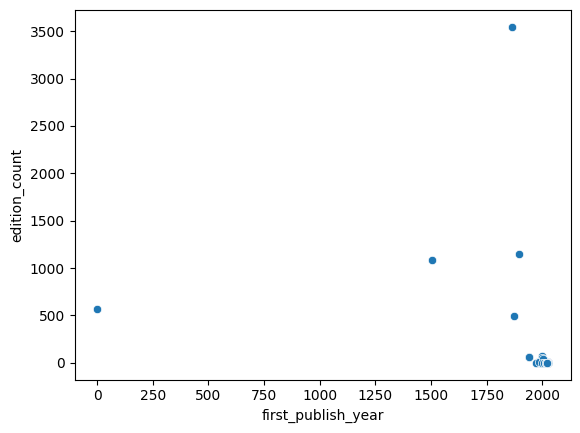

In [54]:
scatter_plot_series = sns.scatterplot(data= data_book, x = "first_publish_year",y = "edition_count")

scatter_plot_series


### Strong assumption

Assuming that the first book who talks about data science was pubblisced in 1974 according to  the article [A Brief History of Data Science](https://www.dataversity.net/articles/brief-history-data-science/#:~:text=Learn%20More-,From%20the%201960s%20to%20the%20Present,data%20into%20information%20and%20knowledge.%E2%80%9D) I decided modify with the default date 1980.

<Axes: xlabel='first_publish_year', ylabel='edition_count'>

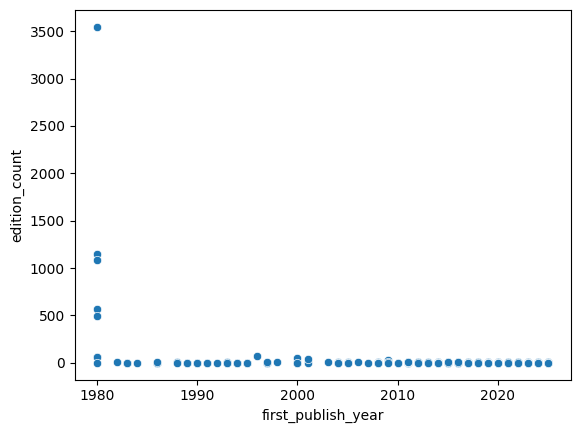

In [55]:
data_book.loc[data_book["first_publish_year"]<1974, "first_publish_year" ] = 1980

scatter_plot_series_2= sns.scatterplot(data= data_book, x = "first_publish_year",y = "edition_count")

scatter_plot_series_2

# Outlier Management

### Fixing the outliers with Robust scaler and log transformation 

As we can observe in the picture *scatter_plot_series_2* are present a bounch of outlier, consequently I decided to mitigate the skewness of the data and outlier using `RobustScaler` and numpy function `log1p(x)`

In [56]:
from sklearn.preprocessing import RobustScaler

data_book["edition_count_log"] = np.log1p(data_book["edition_count"])

scaler = RobustScaler()
data_book[["year_scaled", "edition_scaled","edition_count_log_scale"]] = scaler.fit_transform(data_book[["first_publish_year", "edition_count","edition_count_log"]])

data_book.head()



,title,authors,first_publish_year,edition_count,publishers,isbn,subjects,description,edition_count_log,year_scaled,edition_scaled,edition_count_log_scale
0,Why Machines Learn,Anil Ananthaswamy,2024.0,4,NaN,NaN,Science,not specified,1.609438,1.0,1.5,1.321928
1,The Time Machine,H. G. Wells,1980.0,1146,NaN,NaN,"Self-experimentation in medicine in fiction, F...","The Time Traveller, a dreamer obsessed with tr...",7.044905,-7.8,572.5,9.163650
2,Machine learning,"Kevin P. Murphy, Kevin P. Murphy",2012.0,4,NaN,NaN,"Probabilities, Machine learning, Probability, ...","""This textbook offers a comprehensive and self...",1.609438,-1.4,1.5,1.321928
3,Introduction to Machine Learning with Python,"Andreas C. Mueller, Sarah Guido",2016.0,2,NaN,NaN,"Programming languages (Electronic computers), ...",not specified,1.098612,-0.6,0.5,0.584963
4,Machine learning,Ethem Alpaydin,2016.0,4,NaN,NaN,"Artificial intelligence, Machine learning, Non...",A concise overview of machine learning -- comp...,1.609438,-0.6,1.5,1.321928


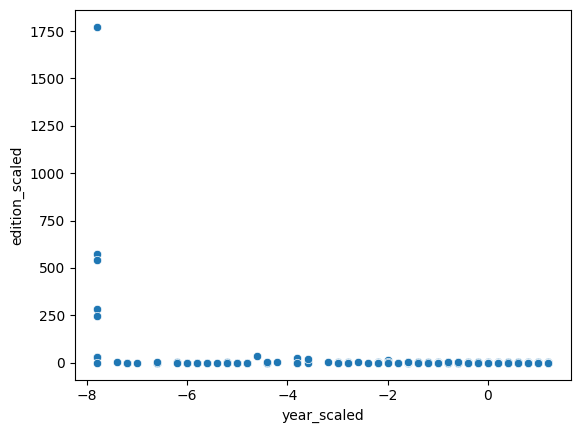

In [57]:
scatter_plot_series_3 = sns.scatterplot(data = data_book, x = "year_scaled", y = "edition_scaled" )



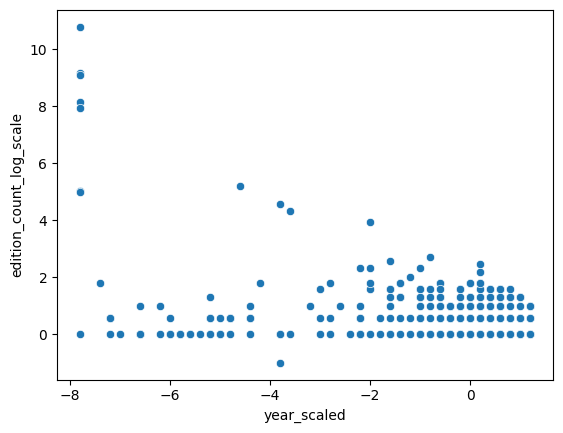

In [58]:
scatter_plot_series_4 = sns.scatterplot(data=data_book, y = "edition_count_log_scale", x = "year_scaled" )

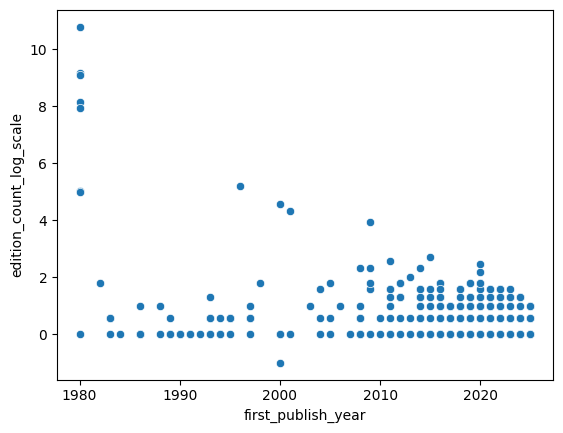

In [59]:
scatter_plot_series_5 = sns.scatterplot(data=data_book, y = "edition_count_log_scale", x = "first_publish_year" )

# Features implementation

I decided to create a new feature *Final_Score* aggregating the features *first_publish_year* and *edition_count* this operation allows me to run better the data for KNN 

In [60]:
keyword = "python"
data_book["relevant"] = data_book.apply(lambda row: keyword.lower() in str(row['subjects']).lower() 
                          or keyword.lower() in str(row['description']).lower(), axis=1)

data_book_filtered= data_book[data_book["relevant"]] 

data_book_filtered

,title,authors,first_publish_year,edition_count,publishers,isbn,subjects,description,edition_count_log,year_scaled,edition_scaled,edition_count_log_scale,relevant
3,Introduction to Machine Learning with Python,"Andreas C. Mueller, Sarah Guido",2016.0,2,NaN,NaN,"Programming languages (Electronic computers), ...",not specified,1.098612,-0.6,0.5,0.584963,True
6,"Hands-On Machine Learning with Scikit-Learn, K...",Aurélien Géron,2019.0,4,NaN,NaN,"machine learning, Mathematics","Through a series of recent breakthroughs, deep...",1.609438,0.0,1.5,1.321928,True
19,Python machine learning,Sebastian Raschka,2015.0,4,NaN,NaN,"Python (Computer program language), Machine le...",Machine learning and predictive analytics are ...,1.609438,-0.8,1.5,1.321928,True
76,Python machine learning from scratch,Jonathan Adam,2016.0,1,NaN,NaN,"Machine learning, Python (Computer program lan...",not specified,0.693147,-0.6,0.0,0.000000,True
153,Python Machine Learning,Wei-Meng Lee,2019.0,3,NaN,NaN,"Machine learning, Python (computer program lan...",not specified,1.386294,0.0,1.0,1.000000,True
253,Python Machine Learning,Wei-Meng Lee,2019.0,1,NaN,NaN,"Machine learning, Python (computer program lan...",not specified,0.693147,0.0,0.0,0.000000,True
353,Hyperparameter Optimization in Machine Learning,Tanay Agrawal,2020.0,2,NaN,NaN,"Python (computer program language), Open sourc...",not specified,1.098612,0.2,0.5,0.584963,True
476,Supervised Machine Learning with Python,Taylor Smith,2019.0,1,NaN,NaN,"Machine learning, Python (computer program lan...",not specified,0.693147,0.0,0.0,0.000000,True
478,Ensemble Machine Learning Cookbook,"Dipayan Sarkar, Vijayalakshmi Natarajan",2019.0,2,NaN,NaN,"Machine learning, Python (computer program lan...",not specified,1.098612,0.0,0.5,0.584963,True
488,Python Machine Learning: Machine Learning and ...,"Sebastian Raschka, Vahid Mirjalili",2017.0,1,NaN,NaN,"Python (computer program language), Machine le...",not specified,0.693147,-0.4,0.0,0.000000,True


In [71]:
data_book_filtered["Final_Score"]= (0.5*data_book_filtered["edition_count_log_scale"] +
                                     0.5*(abs(data_book_filtered["year_scaled"]-data_book_filtered["year_scaled"].min())))


data_book_filtered_clean = data_book_filtered.drop(columns=['publishers', 'isbn'])


C:\Users\Utente\AppData\Local\Temp\ipykernel_2772\3668899296.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_book_filtered["Final_Score"]= (0.5*data_book_filtered["edition_count_log_scale"] +


In [72]:
top_5 = data_book_filtered.sort_values(by = "Final_Score", ascending=False).head(5)
top_5

,title,authors,first_publish_year,edition_count,publishers,isbn,subjects,description,edition_count_log,year_scaled,edition_scaled,edition_count_log_scale,relevant,Final_Score
6,"Hands-On Machine Learning with Scikit-Learn, K...",Aurélien Géron,2019.0,4,NaN,NaN,"machine learning, Mathematics","Through a series of recent breakthroughs, deep...",1.609438,0.0,1.5,1.321928,True,1.060964
153,Python Machine Learning,Wei-Meng Lee,2019.0,3,NaN,NaN,"Machine learning, Python (computer program lan...",not specified,1.386294,0.0,1.0,1.000000,True,0.900000
353,Hyperparameter Optimization in Machine Learning,Tanay Agrawal,2020.0,2,NaN,NaN,"Python (computer program language), Open sourc...",not specified,1.098612,0.2,0.5,0.584963,True,0.792481
478,Ensemble Machine Learning Cookbook,"Dipayan Sarkar, Vijayalakshmi Natarajan",2019.0,2,NaN,NaN,"Machine learning, Python (computer program lan...",not specified,1.098612,0.0,0.5,0.584963,True,0.692481
19,Python machine learning,Sebastian Raschka,2015.0,4,NaN,NaN,"Python (Computer program language), Machine le...",Machine learning and predictive analytics are ...,1.609438,-0.8,1.5,1.321928,True,0.660964


In [73]:
for i,row in top_5.iterrows():
    print(f"Author:{row["authors"]}|  Year: {row["first_publish_year"]}|  Editions: {row['edition_count']}")

Author:Aurélien Géron|  Year: 2019.0|  Editions: 4
Author:Wei-Meng Lee|  Year: 2019.0|  Editions: 3
Author:Tanay Agrawal|  Year: 2020.0|  Editions: 2
Author:Dipayan Sarkar, Vijayalakshmi Natarajan|  Year: 2019.0|  Editions: 2
Author:Sebastian Raschka|  Year: 2015.0|  Editions: 4


# KNN recommender system for online shops

I decided to fit a KNN to predict a racommended book for the online shops, assuming to implement a Recommender “content-based”.

In [74]:
from sklearn.neighbors import NearestNeighbors

features = ['edition_count_log_scale', 'year_scaled', 'Final_Score']

X = data_book_filtered[features]

I created the `X` to isolated the numerical features to use in KNN, using the following features `edition_count_log_scale`, `year_scaled`and  `Final_Score`.

In [75]:
knn_model = NearestNeighbors(n_neighbors = 6, metric= "cosine",algorithm =  "brute" )
knn_model.fit(X)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


### Assumption

I supposed that we want to raccomend a book for `Python`, for that reason I created the  `book_index`.

In [83]:

data_book_filtered = data_book_filtered.copy().reset_index(drop=True)


X = data_book_filtered[features].values

book_index = data_book_filtered[data_book_filtered["description"].str.contains("Python", case=False, na=False)].index[0]
distances, indices = knn_model.kneighbors([X[book_index]], n_neighbors=6)

print("Top 5 Books Suggest:")
for i in range(1, len(distances.flatten())):  # partiamo da 1 per ignorare se stesso
    idx = indices.flatten()[i]
    book = data_book_filtered.iloc[idx]
    print(f"{book['authors']} | {book['first_publish_year']} | {book['edition_count']} edition")

Top 5 Books Suggest:
Wei-Meng Lee | 2019.0 | 3 edition
Dipayan Sarkar, Vijayalakshmi Natarajan | 2019.0 | 2 edition
Tanay Agrawal | 2020.0 | 2 edition
Sebastian Raschka | 2015.0 | 4 edition
Andreas C. Mueller, Sarah Guido | 2016.0 | 2 edition


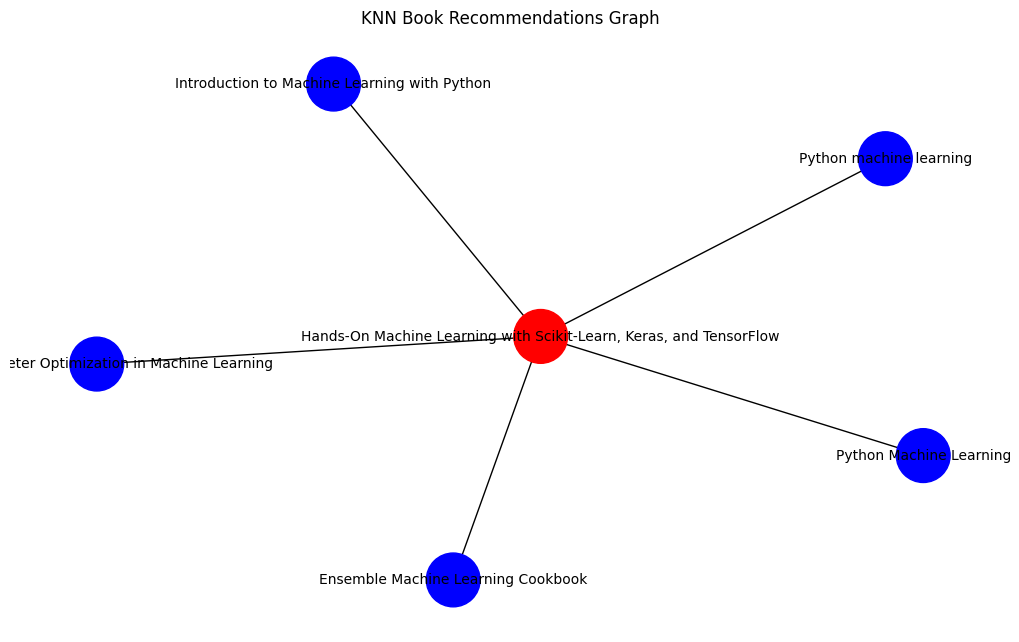

In [84]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.Graph()

# Add main book node
main_book_title = data_book_filtered.loc[book_index, 'title']
G.add_node(main_book_title, color='red')

# Add neighbors
for i in range(1, len(indices.flatten())):
    idx = indices.flatten()[i]
    title = data_book_filtered.loc[idx, 'title']
    G.add_node(title, color='blue')
    G.add_edge(main_book_title, title, weight=1-distances.flatten()[i])  # similarity as edge weight

# Plot the graph
colors = [G.nodes[n]['color'] for n in G.nodes()]
pos = nx.spring_layout(G, seed=42)  # layout
plt.figure(figsize=(10,6))
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=1500, font_size=10)
plt.title("KNN Book Recommendations Graph")
plt.show()

